In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os 
lencat=len(os.listdir("D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Cat"))
lendog=len(os.listdir("D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog"))

In [3]:
print("-"*28)
print(f"Length of Cat Dataset:{lencat}")
print(f"Length of Dog Dataset:{lendog}")
print("-"*28)

----------------------------
Length of Cat Dataset:12490
Length of Dog Dataset:12470
----------------------------


In [4]:
from PIL import Image
import random

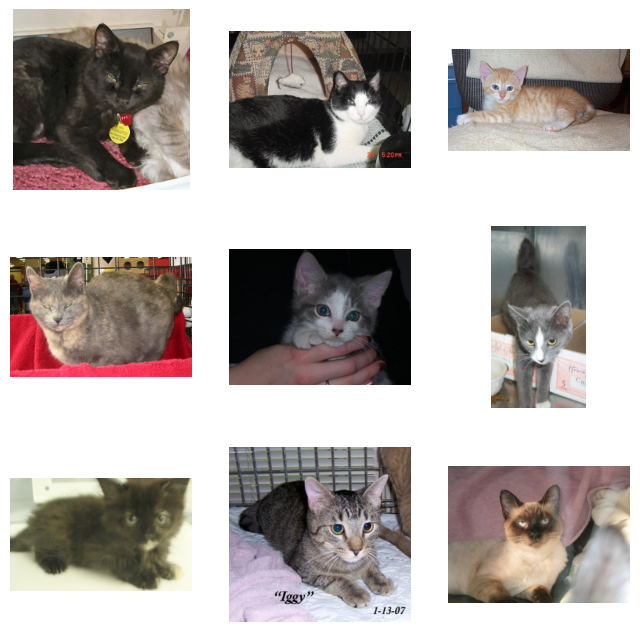

In [5]:
folder="D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Cat"
images=random.sample(os.listdir(folder),9)
plt.figure(figsize=(8,8))
for i, imgname in enumerate(images,start=1):
    img = Image.open(os.path.join(folder, imgname))
    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.axis("off")
plt.show()


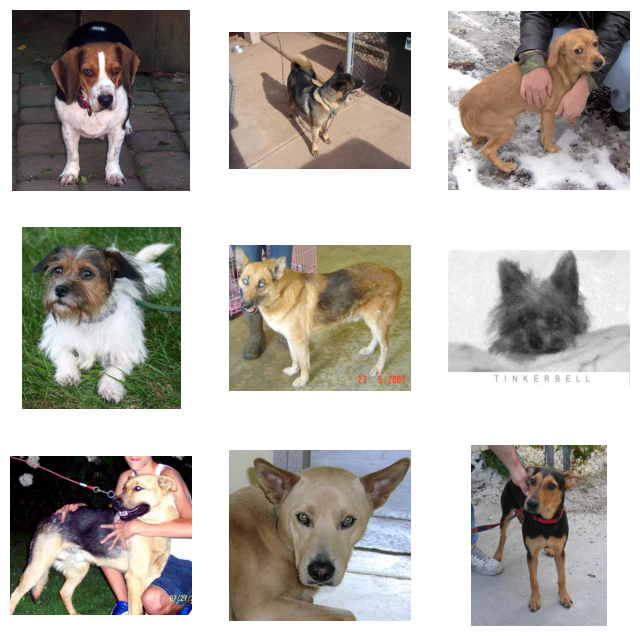

In [6]:
folderd="D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog"
imagesd=random.sample(os.listdir(folderd),9)
plt.figure(figsize=(8,8))
for i,img in enumerate(imagesd,start=1):
    image=Image.open(os.path.join(folderd,img))
    plt.subplot(3,3,i)
    plt.imshow(image)
    plt.axis("off")
plt.show()


In [7]:
corruptc=[]
for i in os.listdir(folder):
    path=os.path.join(folder,i)
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            if img.mode != "RGB":
                corruptc.append(path)
    except Exception:
        corruptc.append(path)
print("Corrupt images:", len(corruptc))

Corrupt images: 28


In [8]:
for img in corruptc:
    os.remove(img)

In [9]:
corruptd=[]
for i in os.listdir(folderd):
    path=os.path.join(folderd,i)
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            if img.mode != "RGB":
             corruptd.append(path)
    except Exception:
        corruptd.append(path)
print("Corrupt images:", len(corruptd))
for path in corruptd:
    os.remove(path)

Corrupt images: 34


In [18]:
import os
import tensorflow as tf
from PIL import Image

path = r"D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages"
bad_files = []

for root, _, files in os.walk(path):
    for file in files:
        filepath = os.path.join(root, file)
        if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        try:
            raw_bytes = tf.io.read_file(filepath)
            tf.io.decode_image(raw_bytes, channels=3, expand_animations=False)
        except Exception as e:
            print(f"Found bad file: {filepath}")
            bad_files.append(filepath)

for filepath in bad_files:
    try:
        os.remove(filepath)
        print(f"Successfully deleted: {filepath}")
    except Exception as e:
        print(f"Could not delete {filepath}: {e}")

print(f"\nCleanup complete! Removed {len(bad_files)} bad images.")

Found bad file: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Cat\4351.jpg
Found bad file: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\11233.jpg
Found bad file: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\11912.jpg
Found bad file: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\2317.jpg
Found bad file: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\2494.jpg
Found bad file: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\9500.jpg
Successfully deleted: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Cat\4351.jpg
Successfully deleted: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\11233.jpg
Successfully deleted: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\11912.jpg
Successfully deleted: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\2317.jpg
Successfully deleted: D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages\Dog\2494.jpg
Successfu

In [25]:
import tensorflow as tf
train=tf.keras.utils.image_dataset_from_directory(
    "D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150, 150),
    batch_size=32
)

Found 24892 files belonging to 2 classes.
Using 19914 files for training.


In [26]:
test=tf.keras.utils.image_dataset_from_directory(
    "D:\CatsvsDog\CatsvsDogs\kagglecatsanddogs_3367a\PetImages",
    seed=42,
    validation_split=0.2,
    subset="validation",
    image_size=(150,150),
    batch_size=32
)

Found 24892 files belonging to 2 classes.
Using 4978 files for validation.


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dropout,
    BatchNormalization,
    Activation,
    Input,
    GlobalAveragePooling2D,
    Rescaling,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast,
    RandomBrightness,
    RandomTranslation,
    RandomCrop,
    RandomHeight,
    RandomWidth
)
from tensorflow.keras.optimizers import (
    Adam,
    SGD,
    RMSprop,
    AdamW,
    Adagrad
)
from tensorflow.keras.losses import (
    BinaryCrossentropy,
    CategoricalCrossentropy,
    SparseCategoricalCrossentropy,
    MeanSquaredError,
    MeanAbsoluteError
)
from tensorflow.keras.metrics import (
    Accuracy,
    BinaryAccuracy,
    CategoricalAccuracy,
    SparseCategoricalAccuracy,
    Precision,
    Recall,
    AUC,
    MeanSquaredError,
    MeanAbsoluteError
)
from tensorflow.keras.callbacks import EarlyStopping


In [27]:
from tensorflow.keras import layers
dataaugmentation=Sequential([
    layers.RandomFlip('vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [28]:
model=Sequential([
    dataaugmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),#Sigmoid bcz i need 0 or 1 output
])

In [29]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [30]:
earlystop=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [31]:
history=model.fit(train,validation_data=test,epochs=20,callbacks=[earlystop],verbose=1)

Epoch 1/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 403s 632ms/step - accuracy: 0.5980 - loss: 1.0783 - val_accuracy: 0.6693 - val_loss: 0.6052
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 376s 602ms/step - accuracy: 0.6665 - loss: 0.6137 - val_accuracy: 0.5747 - val_loss: 0.8594
Epoch 3/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 241s 377ms/step - accuracy: 0.6607 - loss: 0.6223 - val_accuracy: 0.6404 - val_loss: 0.6180
Epoch 4/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 187s 300ms/step - accuracy: 0.6836 - loss: 0.5897 - val_accuracy: 0.5944 - val_loss: 0.7628
Epoch 5/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 177s 284ms/step - accuracy: 0.7041 - loss: 0.5743 - val_accuracy: 0.7003 - val_loss: 0.5799
Epoch 6/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 204s 328ms/step - accuracy: 0.7119 - loss: 0.5577 - val_accuracy: 0.6004 - val_loss: 0.8416
Epoch 7/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 454s 729ms/step - accuracy: 0.7219 - loss: 0.5473 - val_accuracy: 0.6874 - val_loss: 1.0749
Epoch 8/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 194s 311ms/step - accuracy: 0.7369 -

In [32]:
test_loss, test_acc = model.evaluate(test)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

156/156 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.7569 - loss: 0.5067
Final Test Accuracy: 75.69%
Final Test Loss: 0.5067


In [33]:
#model 2
data_augmentation = Sequential([
    layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2)
])

In [34]:
model2=Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),#Sigmoid bcz i need 0 or 1 output
])

In [36]:
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [37]:
early_stopping2=EarlyStopping(monitor='val_loss',patience=6,restore_best_weights=True)

In [ ]:
history2=model2.fit(train,validation_data=test,epochs=20,callbacks=[early_stopping2],verbose=1)

Epoch 1/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 474s 745ms/step - accuracy: 0.6314 - loss: 0.6507 - val_accuracy: 0.6378 - val_loss: 0.6814
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 351s 562ms/step - accuracy: 0.7080 - loss: 0.5651 - val_accuracy: 0.7123 - val_loss: 0.5921
Epoch 3/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 195s 312ms/step - accuracy: 0.7468 - loss: 0.5179 - val_accuracy: 0.6414 - val_loss: 0.7219
Epoch 4/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 171s 274ms/step - accuracy: 0.7723 - loss: 0.4785 - val_accuracy: 0.7523 - val_loss: 0.5196
Epoch 5/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 262s 421ms/step - accuracy: 0.7946 - loss: 0.4453 - val_accuracy: 0.8070 - val_loss: 0.4536
Epoch 6/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 645s 1s/step - accuracy: 0.8128 - loss: 0.4211 - val_accuracy: 0.7963 - val_loss: 0.4713
Epoch 7/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 419s 615ms/step - accuracy: 0.8235 - loss: 0.4045 - val_accuracy: 0.7951 - val_loss: 0.5239
Epoch 8/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 377s 604ms/step - accuracy: 0.8344 - lo